In [13]:
# api for yahoo finance
# stock name () from 2022-2024
# test 2025
# validate 2026

In [28]:
# data cleaning CAN REMOVE????
import numpy as np
import pandas as pd
import yfinance as yf
from typing import Dict, Tuple

# ── Tickers ──────────────────────────────────────────────────────────────────
TICKERS = {
    "XOM":  "Exxon Mobil",
    "CVX":  "Chevron",
    "COP":  "ConocoPhillips",
    "OXY":  "Occidental Petroleum",
   # "PXD":  "Pioneer Natural Resources",
    "SLB":  "Schlumberger (Services)",
    "HAL":  "Halliburton (Services)",
    "EOG":  "EOG Resources",
    "DVN":  "Devon Energy",
    "MPC":  "Marathon Petroleum (Downstream)",

    # stocks added by Ryan

    #"PLC": "Principal U.S. Large-Cap Multi-Factor ETF",
    "FANG": "Diamondback Energy, Inc",
    "PSX": "Phillips 66",
    "VLO": "Valero Energy Corporation" ,
    "CTRA": "Coterra Energy Inc",
    "APA":  "Apache Corp"
}

# ── Date windows ─────────────────────────────────────────────────────────────
TRAIN_START = "2022-01-01"
TRAIN_END   = "2024-12-31"
TEST_START  = "2025-01-01"
TEST_END    = "2025-12-31"
VAL_START   = "2026-01-01"
VAL_END     = "2026-04-22"   # today

# ── Pull data ─────────────────────────────────────────────────────────────────
def fetch_prices(tickers: dict, start: str, end: str) -> pd.DataFrame:
    """
    Returns a MultiIndex DataFrame: (Date) x (ticker, OHLCV field).
    Drops tickers that return no data and prints a warning.
    """
    symbols = list(tickers.keys())
    raw = yf.download(
        tickers=symbols,
        start=start,
        end=end,
        auto_adjust=True,   # adjusts for splits/dividends automatically
        progress=False,
    )

    # yfinance returns MultiIndex columns: (field, ticker)
    # Reorder to (ticker, field) for easier slicing
    raw.columns = raw.columns.swaplevel(0, 1)
    raw.sort_index(axis=1, inplace=True)

    # Warn on any completely empty ticker
    for sym in symbols:
        if sym not in raw.columns.get_level_values(0):
            print(f"⚠️  No data returned for {sym} ({tickers[sym]})")

    return raw


train_df = fetch_prices(TICKERS, TRAIN_START, TRAIN_END)
test_df  = fetch_prices(TICKERS, TEST_START,  TEST_END)
val_df   = fetch_prices(TICKERS, VAL_START,   VAL_END)

print(f"Train:    {train_df.index[0].date()} → {train_df.index[-1].date()}  "
      f"({len(train_df)} trading days)")
print(f"Test:     {test_df.index[0].date()}  → {test_df.index[-1].date()}   "
      f"({len(test_df)} trading days)")
print(f"Validate: {val_df.index[0].date()}  → {val_df.index[-1].date()}   "
      f"({len(val_df)} trading days)")

In [29]:
# full data cleaning pipeline

import numpy as np
import pandas as pd
import yfinance as yf
from typing import Dict, Tuple

# Config

TICKERS = {
    "XOM": "Exxon Mobil",
    "CVX": "Chevron",
    "COP": "ConocoPhillips",
    "OXY": "Occidental Petroleum",
    "SLB": "Schlumberger (Services)",
    "HAL": "Halliburton (Services)",
    "EOG": "EOG Resources",
    "DVN": "Devon Energy",
    "MPC": "Marathon Petroleum (Downstream)",
    "FANG": "Diamondback Energy, Inc",
    "PSX": "Phillips 66",
    "VLO": "Valero Energy Corporation" ,
    "CTRA": "Coterra Energy Inc",
    "APA":  "Apache Corp"
}

# Full pull window (includes pre-train context for warm-up windows)
FULL_START  = "2020-01-01"
FULL_END    = "2026-04-22"

TRAIN_START = "2022-01-01"
TRAIN_END   = "2024-12-31"
VAL_START   = "2025-01-01"
VAL_END     = "2025-12-31"
TEST_START  = "2026-01-01"
TEST_END    = "2026-04-22"

WINDOW_SIZE = 30   # rolling input window for the LSTM


# Step 1: Fetch Raw Data

def fetch_raw(tickers: Dict[str, str], start: str, end: str) -> pd.DataFrame:
    """
    Downloads OHLCV data for all tickers.
    Returns a MultiIndex DataFrame indexed by Date, columns = (ticker, field).
    """
    symbols = list(tickers.keys())
    raw = yf.download(
        tickers=symbols,
        start=start,
        end=end,
        auto_adjust=True,   # split/dividend adjusted
        progress=False,
    )
    # yfinance returns (field, ticker); swap to (ticker, field)
    raw.columns = raw.columns.swaplevel(0, 1)
    raw.sort_index(axis=1, inplace=True)

    missing = [s for s in symbols if s not in raw.columns.get_level_values(0)]
    if missing:
        print(f"⚠️  No data for: {missing}")

    return raw


# Step 2: Per-Ticker Cleaning

def clean_ticker(raw, ticker):
    t = raw[ticker].copy()

    # Forward-fill across holidays / gaps, keep business days only
    full_idx = pd.date_range(t.index.min(), t.index.max(), freq="D")
    t = t.reindex(full_idx).ffill()
    t = t[t.index.dayofweek < 5]

    # Drop zero-volume days
    t = t[t["Volume"] > 0].copy()

    # Log return
    t["log_return"] = np.log(t["Close"] / t["Close"].shift(1))

    # LSTM feature set
    t["hl_range"]        = np.log(t["High"] / t["Low"])
    t["body"]            = np.log(t["Close"] / t["Open"])
    t["upper_shadow"]    = np.log(t["High"] / t[["Open", "Close"]].max(axis=1))
    t["lower_shadow"]    = np.log(t[["Open", "Close"]].min(axis=1) / t["Low"])
    t["log_volume"]      = np.log1p(t["Volume"])
    t["realized_vol_20"] = t["log_return"].rolling(20).std()

    for lag in [5, 10, 21]:
        t[f"mom_{lag}d"] = t["Close"].pct_change(lag)

    # ← was dropna(subset=["log_return"]) only — now drops any row where ANY feature is NaN
    t = t.dropna(subset=FEATURE_COLS)

    t["ticker"] = ticker
    return t


def clean_all_tickers(raw: pd.DataFrame, tickers: Dict[str, str]) -> pd.DataFrame:
    """Runs clean_ticker on every symbol and concatenates into one long DataFrame."""
    frames = []
    for sym in tickers:
        if sym not in raw.columns.get_level_values(0):
            continue
        cleaned = clean_ticker(raw, sym)
        frames.append(cleaned)
        print(f"  ✓ {sym:4s}  {cleaned.index[0].date()} → {cleaned.index[-1].date()}  "
              f"({len(cleaned)} rows)")
    return pd.concat(frames).sort_index()


# Step 3: Z-score Normalization (train window only)

FEATURE_COLS = [
    "log_return", "hl_range", "body", "upper_shadow", "lower_shadow",
    "log_volume", "realized_vol_20", "mom_5d", "mom_10d", "mom_21d",
]

def compute_train_stats(long_df: pd.DataFrame,
                        train_start: str,
                        train_end: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Computes per-ticker mean and std over the TRAINING window only.
    These stats are then applied to all splits to prevent lookahead bias.

    Returns (means_df, stds_df) — both indexed by ticker.
    """
    mask = (long_df.index >= train_start) & (long_df.index <= train_end)
    train_only = long_df[mask]

    means = train_only.groupby("ticker")[FEATURE_COLS].mean()
    stds  = train_only.groupby("ticker")[FEATURE_COLS].std().replace(0, 1)  # avoid /0
    return means, stds


def normalize(long_df: pd.DataFrame,
              means: pd.DataFrame,
              stds: pd.DataFrame) -> pd.DataFrame:
    """
    Applies z-score normalization using pre-computed train stats.
    Each ticker is normalized independently.
    """
    df = long_df.copy()
    for sym in df["ticker"].unique():
        mask = df["ticker"] == sym
        df.loc[mask, FEATURE_COLS] = (
            (df.loc[mask, FEATURE_COLS] - means.loc[sym]) / stds.loc[sym]
        )
    return df


# Step 4: Rolling 30-day Windows

def build_windows(normalized_df: pd.DataFrame,
                  window_size: int = WINDOW_SIZE) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    For each ticker independently, constructs overlapping 30-day windows.

    Returns:
        X      : (N, window_size, n_features)  — LSTM input
        y      : (N,)                           — next-day log return (regression target)
        labels : (N,)                           — 5-class bucket (for LSTM classifier head)
                  0=strong sell, 1=mild sell, 2=neutral, 3=mild buy, 4=strong buy
        meta   : list of (ticker, date) for each sample
    """
    X_list, y_list, label_list, meta_list = [], [], [], []

    # Bucket thresholds (approximate quintiles; tune on training set if desired)
    THRESHOLDS = [-0.8, -0.2, 0.2, 0.8]     # strong_sell | mild_sell | neutral | mild_buy | strong_buy

    for sym, grp in normalized_df.groupby("ticker"):
        grp = grp.sort_index()
        feat = grp[FEATURE_COLS].values        # (T, F)
        rets = grp["log_return"].values         # raw (un-normalized) returns for labels

        # We need the UN-normalized returns for bucketing; pull from the original
        # (we stored normalized log_return in feat, but label bucketing should use
        #  the original scale — easier to just use normalized here with matching thresholds,
        #  or re-derive; for simplicity we use normalized returns with std-scaled thresholds)
        for t in range(window_size, len(grp) - 1):          # -1 so t+1 exists
            window = feat[t - window_size : t]              # (30, F)
            next_ret = grp["log_return"].iloc[t + 1]        # prediction target (normalized)
            date = grp.index[t]

            # 5-class label
            if   next_ret <= THRESHOLDS[0]: label = 0
            elif next_ret <= THRESHOLDS[1]: label = 1
            elif next_ret <= THRESHOLDS[2]: label = 2
            elif next_ret <= THRESHOLDS[3]: label = 3
            else:                           label = 4

            X_list.append(window)
            y_list.append(next_ret)
            label_list.append(label)
            meta_list.append((sym, date))

    X      = np.stack(X_list,     axis=0).astype(np.float32)
    y      = np.array(y_list,     dtype=np.float32)
    labels = np.array(label_list, dtype=np.int64)

    return X, y, labels, meta_list


# Step 5: Split by Date

def split_windows(X, y, labels, meta, split_date_1, split_date_2):
    """
    Splits (X, y, labels) arrays into train / val / test
    based on the DATE of the last day in each window (stored in meta).
    """
    dates = pd.to_datetime([m[1] for m in meta])
    d1 = pd.Timestamp(split_date_1)
    d2 = pd.Timestamp(split_date_2)

    tr  = dates <= d1
    v   = (dates > d1) & (dates <= d2)
    te  = dates > d2

    splits = {}
    for name, mask in [("train", tr), ("val", v), ("test", te)]:
        splits[name] = {
            "X":      X[mask],
            "y":      y[mask],
            "labels": labels[mask],
            "meta":   [m for m, flag in zip(meta, mask) if flag],
        }
        print(f"  {name:5s}  {mask.sum():5d} windows   "
              f"class dist: {np.bincount(labels[mask], minlength=5)}")
    return splits


# Main

if __name__ == "__main__":

    print("=" * 60)
    print("Step 1 — Fetching raw OHLCV data …")
    raw = fetch_raw(TICKERS, FULL_START, FULL_END)
    print(f"  Raw shape: {raw.shape}  ({len(raw)} trading days × {raw.shape[1]} columns)")

    print("\nStep 2 — Cleaning each ticker …")
    long_df = clean_all_tickers(raw, TICKERS)
    print(f"  Combined shape: {long_df.shape}")

    print("\nStep 3 — Computing z-score stats on TRAIN window only …")
    means, stds = compute_train_stats(long_df, TRAIN_START, TRAIN_END)
    print(f"  Stats computed for: {list(means.index)}")

    print("\n  Normalizing all splits …")
    norm_df = normalize(long_df, means, stds)

    print("\nStep 4 — Building rolling 30-day windows …")
    X, y, labels, meta = build_windows(norm_df, window_size=WINDOW_SIZE)
    print(f"  Total windows: {len(X)}   Shape: {X.shape}")
    print(f"  Overall class distribution: {np.bincount(labels, minlength=5)}")

    print("\nStep 5 — Splitting into train / val / test …")
    splits = split_windows(X, y, labels, meta,
                           split_date_1=TRAIN_END,
                           split_date_2=VAL_END)

    # Sanity checks
    print("\n── Sanity Checks")

    # 1. No data leakage: normalization stats come from train only
    tr_meta_dates = [m[1] for m in splits["train"]["meta"]]
    assert all(d <= pd.Timestamp(TRAIN_END) for d in tr_meta_dates), \
        "Leakage: train windows extend past TRAIN_END"

    # 2. No NaN in windows
    assert not np.isnan(X).any(), "NaN detected in X!"
    assert not np.isnan(y).any(), "NaN detected in y!"

    # 3. Windows are exactly WINDOW_SIZE long
    assert X.shape[1] == WINDOW_SIZE, f"Expected window={WINDOW_SIZE}, got {X.shape[1]}"

    print("  ✓ No lookahead leakage detected")
    print("  ✓ No NaN values in X or y")
    print(f"  ✓ All windows are {WINDOW_SIZE} days long")
    print("  ✓ All checks passed — data is ready for LSTM training")

    # Save
    np.save("X_train.npy",      splits["train"]["X"])
    np.save("y_train.npy",      splits["train"]["y"])
    np.save("labels_train.npy", splits["train"]["labels"])

    np.save("X_val.npy",        splits["val"]["X"])
    np.save("y_val.npy",        splits["val"]["y"])
    np.save("labels_val.npy",   splits["val"]["labels"])

    np.save("X_test.npy",       splits["test"]["X"])
    np.save("y_test.npy",       splits["test"]["y"])
    np.save("labels_test.npy",  splits["test"]["labels"])

    # Save normalization stats for inference time
    means.to_csv("train_means.csv")
    stds.to_csv("train_stds.csv")

    print("\n✅  All arrays saved.")


Step 1 — Fetching raw OHLCV data …
  Raw shape: (1583, 70)  (1583 trading days × 70 columns)

Step 2 — Cleaning each ticker …
  ✓ XOM   2020-01-31 → 2026-04-21  (1623 rows)
  ✓ CVX   2020-01-31 → 2026-04-21  (1623 rows)
  ✓ COP   2020-01-31 → 2026-04-21  (1623 rows)
  ✓ OXY   2020-01-31 → 2026-04-21  (1623 rows)
  ✓ SLB   2020-01-31 → 2026-04-21  (1623 rows)
  ✓ HAL   2020-01-31 → 2026-04-21  (1623 rows)
  ✓ EOG   2020-01-31 → 2026-04-21  (1623 rows)
  ✓ DVN   2020-01-31 → 2026-04-21  (1623 rows)
  ✓ MPC   2020-01-31 → 2026-04-21  (1623 rows)
  ✓ FANG  2020-01-31 → 2026-04-21  (1623 rows)
  ✓ PSX   2020-01-31 → 2026-04-21  (1623 rows)
  ✓ VLO   2020-01-31 → 2026-04-21  (1623 rows)
  ✓ CTRA  2020-01-31 → 2026-04-21  (1623 rows)
  ✓ APA   2020-01-31 → 2026-04-21  (1623 rows)
  Combined shape: (22722, 16)

Step 3 — Computing z-score stats on TRAIN window only …
  Stats computed for: ['APA', 'COP', 'CTRA', 'CVX', 'DVN', 'EOG', 'FANG', 'HAL', 'MPC', 'OXY', 'PSX', 'SLB', 'VLO', 'XOM']

  Nor

In [ ]:
# downloading the dataframes as csv in the drive

train_df.to_csv("Train_Dataset.csv", index=True)
test_df.to_csv("Test_Dataset.csv", index=True)
val_df.to_csv("Validation_Dataset.csv", index=True)

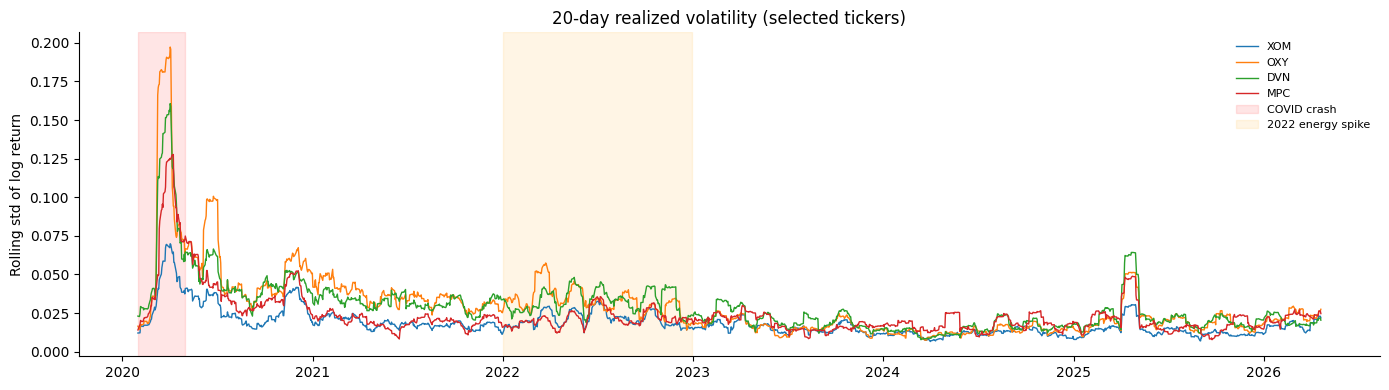

In [30]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

HIGHLIGHT = ["XOM", "OXY", "DVN", "MPC"]

fig, ax = plt.subplots(figsize=(14, 4))
for sym in HIGHLIGHT:
    grp = long_df[long_df["ticker"] == sym]
    ax.plot(grp.index, grp["realized_vol_20"], linewidth=1, label=sym)

ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-05-01"),
           alpha=0.1, color="red", label="COVID crash")
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"),
           alpha=0.1, color="orange", label="2022 energy spike")
ax.set_title("20-day realized volatility (selected tickers)")
ax.set_ylabel("Rolling std of log return")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig_realized_vol.png", dpi=150)
plt.show()

In [31]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

TICKERS = {
    "XOM": "Exxon Mobil", "CVX": "Chevron", "COP": "ConocoPhillips",
    "OXY": "Occidental Petroleum", "SLB": "Schlumberger (Services)",
    "HAL": "Halliburton (Services)", "EOG": "EOG Resources",
    "DVN": "Devon Energy", "MPC": "Marathon Petroleum (Downstream)",
    "FANG": "Diamondback Energy, Inc", "PSX": "Phillips 66",
    "VLO": "Valero Energy Corporation", "CTRA": "Coterra Energy Inc",
    "APA": "Apache Corp"
}
FEATURE_COLS = [
    "log_return", "hl_range", "body", "upper_shadow", "lower_shadow",
    "log_volume", "realized_vol_20", "mom_5d", "mom_10d", "mom_21d",
]
FULL_START, FULL_END   = "2020-01-01", "2026-04-22"
TRAIN_START, TRAIN_END = "2022-01-01", "2024-12-31"

raw = yf.download(list(TICKERS.keys()), start=FULL_START, end=FULL_END,
                  auto_adjust=True, progress=False)
raw.columns = raw.columns.swaplevel(0, 1)
raw.sort_index(axis=1, inplace=True)

frames = []
for sym in TICKERS:
    t = raw[sym].copy()
    t = t.reindex(pd.date_range(t.index.min(), t.index.max(), freq="D")).ffill()
    t = t[t.index.dayofweek < 5]
    t = t[t["Volume"] > 0].copy()
    t["log_return"]      = np.log(t["Close"] / t["Close"].shift(1))
    t["hl_range"]        = np.log(t["High"] / t["Low"])
    t["body"]            = np.log(t["Close"] / t["Open"])
    t["upper_shadow"]    = np.log(t["High"] / t[["Open", "Close"]].max(axis=1))
    t["lower_shadow"]    = np.log(t[["Open", "Close"]].min(axis=1) / t["Low"])
    t["log_volume"]      = np.log1p(t["Volume"])
    t["realized_vol_20"] = t["log_return"].rolling(20).std()
    for lag in [5, 10, 21]:
        t[f"mom_{lag}d"] = t["Close"].pct_change(lag)
    t = t.dropna(subset=FEATURE_COLS)
    t["ticker"] = sym
    frames.append(t)

long_df = pd.concat(frames).sort_index()

train_mask = (long_df.index >= TRAIN_START) & (long_df.index <= TRAIN_END)
means = long_df[train_mask].groupby("ticker")[FEATURE_COLS].mean()
stds  = long_df[train_mask].groupby("ticker")[FEATURE_COLS].std().replace(0, 1)

norm_df = long_df.copy()
for sym in TICKERS:
    m = norm_df["ticker"] == sym
    norm_df.loc[m, FEATURE_COLS] = (
        (norm_df.loc[m, FEATURE_COLS] - means.loc[sym]) / stds.loc[sym]
    )

print("✅ ready — long_df:", long_df.shape, "| norm_df:", norm_df.shape)

✅ ready — long_df: (22722, 16) | norm_df: (22722, 16)


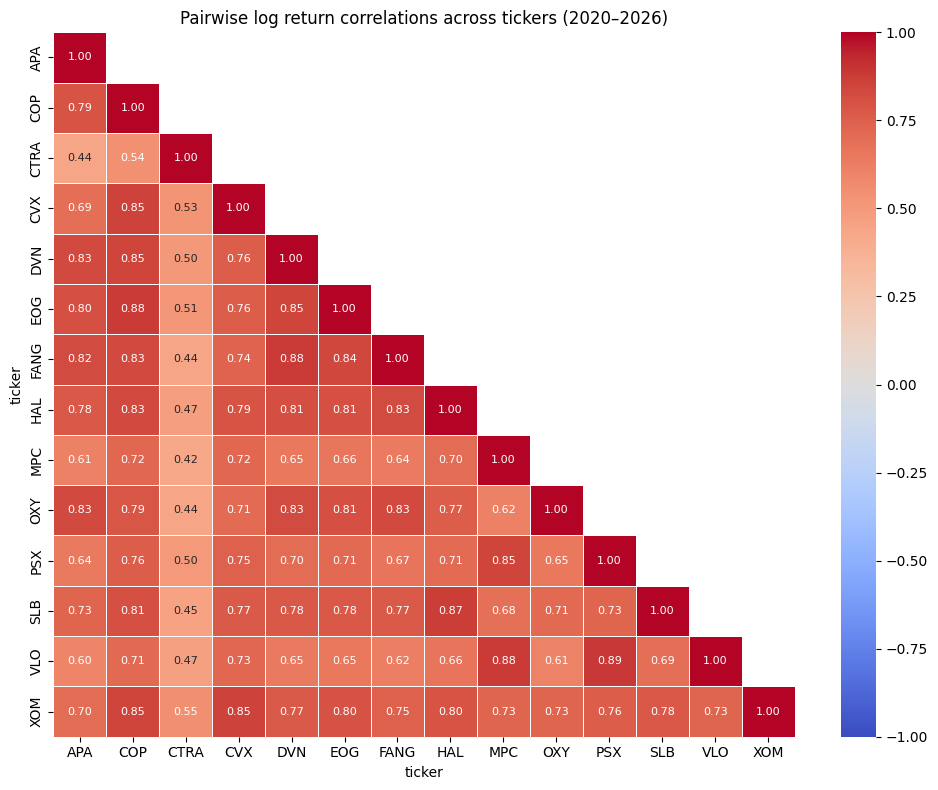

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot to wide format: date x ticker, using normalized log returns
returns_wide = (
    norm_df.reset_index()
    .rename(columns={norm_df.index.name or "index": "Date"})
    .pivot(index="Date", columns="ticker", values="log_return")
)
corr = returns_wide.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1, linewidths=0.4,
    annot_kws={"size": 8}, ax=ax
)
ax.set_title("Pairwise log return correlations across tickers (2020–2026)")
plt.tight_layout()
plt.show()

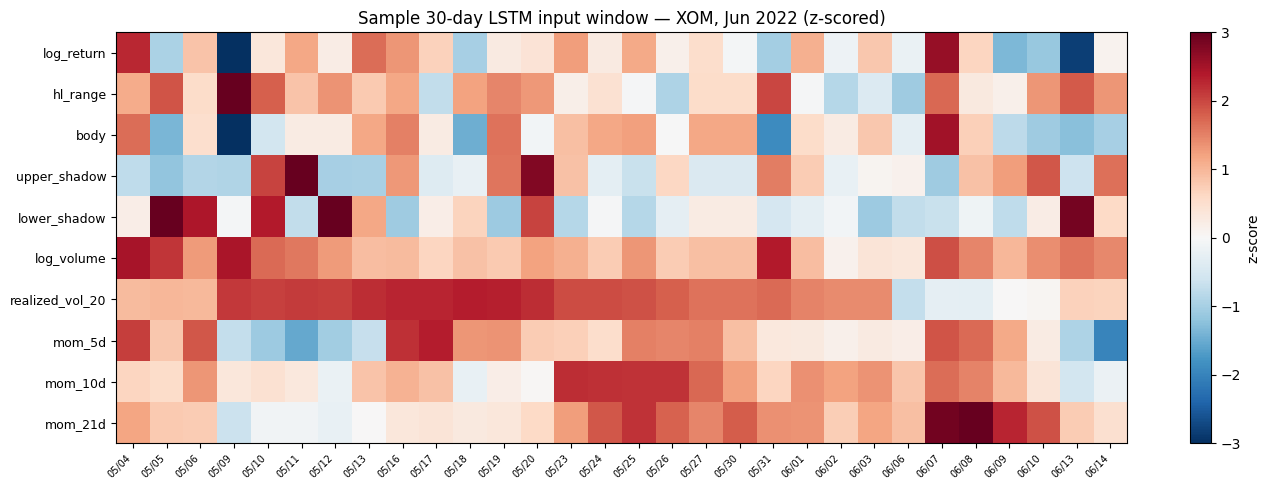

In [34]:
sym = "XOM"
grp = norm_df[norm_df["ticker"] == sym].sort_index()

# grab a window from mid-2022 (high volatility period)
start_idx = grp.index.get_loc(grp.index[grp.index >= "2022-06-15"][0])
sample_window = grp[FEATURE_COLS].iloc[start_idx - 30 : start_idx].T  # (features x 30 days)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(sample_window.values, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_yticklabels(FEATURE_COLS, fontsize=9)
ax.set_xticks(range(30))
ax.set_xticklabels(
    [d.strftime("%m/%d") for d in sample_window.columns],
    rotation=45, ha="right", fontsize=7
)
ax.set_title(f"Sample 30-day LSTM input window — {sym}, Jun 2022 (z-scored)")
plt.colorbar(im, ax=ax, label="z-score")
plt.tight_layout()
plt.show()